Using device: cpu


/dssg/share/conda_env/ms8410/lib/python3.11/site-packages/torch/cuda/amp/grad_scaler.py:120: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.")
/dssg/share/conda_env/ms8410/lib/python3.11/site-packages/torch/amp/autocast_mode.py:204: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 1/200, Avg Loss: 0.7064, LR: 0.001000, Time: 37.97s
Best model saved with loss 0.7064
Epoch 2/200, Avg Loss: 0.6914, LR: 0.001000, Time: 30.83s
Best model saved with loss 0.6914
Epoch 3/200, Avg Loss: 0.6906, LR: 0.000999, Time: 32.80s
Best model saved with loss 0.6906
Epoch 4/200, Avg Loss: 0.6905, LR: 0.000999, Time: 29.11s
Best model saved with loss 0.6905
Epoch 5/200, Avg Loss: 0.6897, LR: 0.000998, Time: 29.02s
Best model saved with loss 0.6897
Epoch 6/200, Avg Loss: 0.6889, LR: 0.000998, Time: 28.90s
Best model saved with loss 0.6889
Epoch 7/200, Avg Loss: 0.6883, LR: 0.000997, Time: 31.65s
Best model saved with loss 0.6883
Epoch 8/200, Avg Loss: 0.6880, LR: 0.000996, Time: 28.47s
Best model saved with loss 0.6880
Epoch 9/200, Avg Loss: 0.6878, LR: 0.000995, Time: 31.89s
Best model saved with loss 0.6878
Epoch 10/200, Avg Loss: 0.6877, LR: 0.000994, Time: 32.58s
Best model saved with loss 0.6877
Epoch 11/200, Avg Loss: 0.6873, LR: 0.000993, Time: 29.85s
Best model saved wit

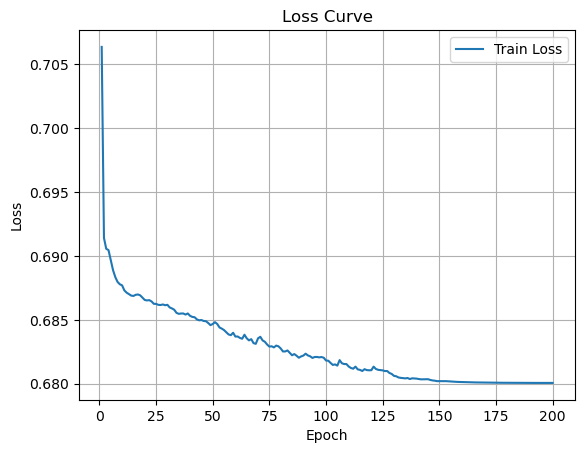

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler  # 混合精度工具
from torch.utils.data import DataLoader, Dataset
from datetime import datetime
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from unet import UNet  # 请确保你的 UNet 定义已经支持单通道输出
S

# 自定义数据集类
class SelfDataSet(Dataset):
    def __init__(self, train_image, train_label):
        # 从 image_path 文件夹中读取图像文件
        self.images = sorted([os.path.join(train_image, f) for f in os.listdir(train_image) if f.endswith('.png')])
        # 从 label_path 文件夹中读取标签文件
        self.labels = sorted([os.path.join(train_label, f) for f in os.listdir(train_label) if f.endswith('.png')])

        # 检查数量是否匹配
        if len(self.images) != len(self.labels):
            raise ValueError(f"Number of images ({len(self.images)}) and labels ({len(self.labels)}) do not match.")
        
        # 检查文件名是否匹配（去掉文件名的路径和扩展名，只保留文件名部分）
        for img, lbl in zip(self.images, self.labels):
            if os.path.basename(img).split('.')[0] != os.path.basename(lbl).split('.')[0]:
                raise ValueError(f"Image {img} and label {lbl} do not match.")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 加载图像和标签
        image = np.array(Image.open(self.images[idx]).convert('L'), dtype=np.float32) / 255.0
        label = np.array(Image.open(self.labels[idx]).convert('L'), dtype=np.float32) / 255.0  # 假设标签为二值化
        return torch.tensor(image).unsqueeze(0), torch.tensor(label).unsqueeze(0)


# 验证集评估函数
def evaluate(net, val_loader, loss_fun, device):
    net.eval()
    val_loss = 0.0
    with torch.no_grad():
        for image, label in val_loader:
            image = image.to(device, dtype=torch.float32)
            label = label.to(device, dtype=torch.float32)  # 单通道标签
            pred = net(image)
            loss = loss_fun(pred, label)
            val_loss += loss.item()
    return val_loss / len(val_loader)


# 尝试使用 GPU
def tryGPU(i=0):
    if torch.cuda.device_count() > i:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')


# 主训练函数
def Train_Unet(net, device, train_image, train_label, batch_size=(), epochs=(), lr=()):
    # 加载训练集
    train_dataset = SelfDataSet(train_image, train_label)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    # 定义优化器、损失函数、学习率调度器和梯度缩放器
    opt = optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    loss_fun = nn.BCEWithLogitsLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = GradScaler()

    # 模型保存目录
    model_dir = "./models/"
    os.makedirs(model_dir, exist_ok=True)

    # 训练信息
    start_epoch = 0
    best_loss = float('inf')
    train_losses = []
    val_losses = []

    for epoch in range(start_epoch, epochs):
        net.train()
        running_loss = 0.0
        start_time = time.perf_counter()

        for image, label in train_loader:
            opt.zero_grad()
            image = image.to(device, dtype=torch.float32)
            label = label.to(device, dtype=torch.float32)  # 单通道标签

            with autocast():
                pred = net(image)  # 输出 [B, 1, H, W]
                loss = loss_fun(pred, label)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)  # 梯度裁剪
            scaler.step(opt)
            scaler.update()

            running_loss += loss.item()

        # 平均训练损失
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        scheduler.step()

        # 打印训练信息
        print(f"Epoch {epoch + 1}/{epochs}, Avg Loss: {avg_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}, "
              f"Time: {time.perf_counter() - start_time:.2f}s")

        # 保存最优模型
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save({'net': net.state_dict(), 'opt': opt.state_dict(), 'epoch': epoch},
                       os.path.join(model_dir, 'model_best.pth'))
            print(f"Best model saved with loss {best_loss:.4f}")

    # 绘制训练和验证损失曲线
    plt.figure()
    plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
    if val_losses:
        plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid()
    plt.savefig(f"loss_curve_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
    print("Training completed. Loss curve saved.")


# 主函数
if __name__ == '__main__':
    torch.backends.cudnn.benchmark = True
    device = tryGPU()
    print(f"Using device: {device}")

    # 定义 U-Net 模型
    net = UNet(1, 1, bilinear=False)  # 单通道输入，单通道输出
    net.to(device=device)

    # 数据路径
    train_image = './train_image/'
    train_label = './train_label/'

    # 开始训练
    Train_Unet(net, device, train_image, train_label, epochs=200, batch_size=16, lr=0.001)